# 2: Exploratory Data Analysis

This notebook performs exploratory data analysis over the Silver layer datasets created in Notebook 1.

Inputs:
- `data/silver/airbnb_clean.parquet`
- `data/silver/licenses_clean.parquet`
- `data/silver/airbnb_license_reference.parquet`

Outputs:
- EDA tables in `reports/tables/`
- EDA figures in `reports/figures/`

The goal is to understand data quality, economic distributions, textual patterns, categorical structure and geographic coverage before creating the final Gold modeling dataset.

This notebook does not train models, create the final target, calculate license proximity features or perform scoring.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.neighbors import BallTree
from sklearn.model_selection import train_test_split
import json
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 160)

In [2]:
def find_project_root(start_path=None, project_folder_name="tool"):
    current_path = Path.cwd() if start_path is None else Path(start_path).resolve()

    for path in [current_path] + list(current_path.parents):
        if path.name == project_folder_name:
            return path

    raise RuntimeError(
        f"Could not find project root folder named '{project_folder_name}'. "
        f"Current working directory is: {Path.cwd()}"
    )


PROJECT_DIR = find_project_root()

DATA_DIR = PROJECT_DIR / "data"
SILVER_DIR = DATA_DIR / "silver"
GOLD_DIR = DATA_DIR / "gold"

REPORTS_DIR = PROJECT_DIR / "reports"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR = REPORTS_DIR / "figures"

AIRBNB_SILVER_PATH = SILVER_DIR / "airbnb_clean.parquet"
LICENSES_SILVER_PATH = SILVER_DIR / "licenses_clean.parquet"
AIRBNB_LICENSE_REFERENCE_PATH = SILVER_DIR / "airbnb_license_reference.parquet"

AIRBNB_LICENSE_ENRICHED_PATH = GOLD_DIR / "airbnb_license_enriched.parquet"
AIRBNB_MODELING_DATASET_PATH = GOLD_DIR / "airbnb_modeling_dataset.parquet"

X_TRAIN_PATH = GOLD_DIR / "X_train.parquet"
X_TEST_PATH = GOLD_DIR / "X_test.parquet"
X_VAL_PATH = GOLD_DIR / "X_val.parquet"
Y_TRAIN_PATH = GOLD_DIR / "y_train.parquet"
Y_TEST_PATH = GOLD_DIR / "y_test.parquet"
Y_VAL_PATH = GOLD_DIR / "y_val.parquet"
FEATURE_CONFIG_PATH = GOLD_DIR / "feature_config.json"

GOLD_DATASET_SUMMARY_PATH = TABLES_DIR / "gold_dataset_summary.csv"
GOLD_TARGET_DISTRIBUTION_PATH = TABLES_DIR / "gold_target_distribution.csv"
GOLD_GEOSPATIAL_FEATURE_SUMMARY_PATH = TABLES_DIR / "gold_geospatial_feature_summary.csv"

print("Gold output directory:", GOLD_DIR)

print("PROJECT_DIR:", PROJECT_DIR)

Gold output directory: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\data\gold
PROJECT_DIR: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool


In [3]:
airbnb = pd.read_parquet(AIRBNB_SILVER_PATH)
licenses = pd.read_parquet(LICENSES_SILVER_PATH)
license_reference = pd.read_parquet(AIRBNB_LICENSE_REFERENCE_PATH)

print("Airbnb Silver shape:", airbnb.shape)
print("Licenses Silver shape:", licenses.shape)
print("License reference shape:", license_reference.shape)

display(airbnb.head())
display(licenses.head())
display(license_reference.head())

Airbnb Silver shape: (19410, 25)
Licenses Silver shape: (6090, 9)
License reference shape: (19410, 2)


,listing_key,text,neighbourhood_group,neighbourhood,municipality,latitude,longitude,has_valid_coordinates,property_type,minimum_nights,availability_365,price,log_price,has_invalid_price,number_of_reviews,last_review,reviews_per_month,number_of_reviews_ltm,calculated_host_listings_count,text_length,word_count,uppercase_ratio,digit_count,exclamation_count,empty_text
0,airbnb_000000,Huge flat for 8 people close to Sagrada Familia,Eixample,la Sagrada Família,la Sagrada Família,41.405560,2.17262,True,Entire home/apt,1,80,210.0,5.347108,False,51,2025-07-31,0.34,7,26,47,9,0.078947,1,0,False
1,airbnb_000001,"Forum CCIB DeLuxe, Spacious, Large Balcony, relax",Sant Martí,el Besòs i el Maresme,el Besòs i el Maresme,41.412432,2.21975,True,Entire home/apt,3,289,285.0,5.652489,False,91,2025-09-08,0.52,12,1,49,7,0.250000,0,0,False
2,airbnb_000002,Sagrada Familia area - Còrsega 1,Gràcia,el Camp d'en Grassot i Gràcia Nova,el Camp d'en Grassot i Gràcia Nova,41.405660,2.17015,True,Entire home/apt,1,64,170.0,5.135798,False,152,2025-08-08,0.88,23,2,32,6,0.120000,1,0,False
3,airbnb_000003,Stylish Top Floor Apartment - Ramblas Plaza Real,Ciutat Vella,el Barri Gòtic,el Barri Gòtic,41.380620,2.17517,True,Entire home/apt,31,333,110.0,4.700480,False,25,2024-11-05,0.14,5,3,48,8,0.175000,0,0,False
4,airbnb_000004,VIDRE HOME PLAZA REAL on LAS RAMBLAS,Ciutat Vella,el Barri Gòtic,el Barri Gòtic,41.379780,2.17623,True,Entire home/apt,5,335,333.0,5.808142,False,271,2025-08-19,1.49,23,3,36,7,0.933333,0,0,False


,license_district,license_neighborhood,license_places,license_x,license_y,license_longitude,license_latitude,license_source_crs,has_valid_coordinates
0,CIUTAT VELLA,el Raval,3.0,2.170172,41.378445,2.170172,41.378445,EPSG:4326,True
1,CIUTAT VELLA,"Sant Pere, Santa Caterina i la Ribera",3.0,2.182004,41.382884,2.182004,41.382884,EPSG:4326,True
2,CIUTAT VELLA,el Barri Gòtic,3.0,2.173086,41.382224,2.173086,41.382224,EPSG:4326,True
3,CIUTAT VELLA,"Sant Pere, Santa Caterina i la Ribera",9.0,2.183305,41.383685,2.183305,41.383685,EPSG:4326,True
4,CIUTAT VELLA,el Raval,8.0,2.167911,41.385020,2.167911,41.385020,EPSG:4326,True


,listing_key,license_raw
0,airbnb_000000,ESFCTU000008058000039706000000000000000HUTB-002062349
1,airbnb_000001,ESFCTU000008106000547162000000000000000000HUTB0050572
2,airbnb_000002,HUTB-001722
3,airbnb_000003,Exempt
4,airbnb_000004,ESFCTU000008119000093652000000000000000HUTB-001506712


In [4]:
overview = pd.DataFrame([
    {
        "dataset": "airbnb_clean",
        "rows": len(airbnb),
        "columns": airbnb.shape[1],
        "duplicate_rows": airbnb.duplicated().sum(),
    },
    {
        "dataset": "licenses_clean",
        "rows": len(licenses),
        "columns": licenses.shape[1],
        "duplicate_rows": licenses.duplicated().sum(),
    },
    {
        "dataset": "airbnb_license_reference",
        "rows": len(license_reference),
        "columns": license_reference.shape[1],
        "duplicate_rows": license_reference.duplicated().sum(),
    },
])

display(overview)

overview.to_csv(TABLES_DIR / "eda_dataset_overview.csv", index=False)

,dataset,rows,columns,duplicate_rows
0,airbnb_clean,19410,25,0
1,licenses_clean,6090,9,0
2,airbnb_license_reference,19410,2,0


## As seen in notebook 1, this is our complete summary for our values

In [5]:
def missing_summary(df, dataset_name):
    return (
        pd.DataFrame({
            "dataset": dataset_name,
            "column": df.columns,
            "missing_rate": [df[col].isna().mean() for col in df.columns],
            "missing_count": [df[col].isna().sum() for col in df.columns],
        })
        .sort_values("missing_rate", ascending=False)
    )


missing_airbnb = missing_summary(airbnb, "airbnb_clean")
missing_licenses = missing_summary(licenses, "licenses_clean")

missing_all = pd.concat([missing_airbnb, missing_licenses], ignore_index=True)

display(missing_all)

missing_all.to_csv(TABLES_DIR / "eda_missing_summary.csv", index=False)

,dataset,column,missing_rate,missing_count
0,airbnb_clean,last_review,0.257032,4989
1,airbnb_clean,reviews_per_month,0.257032,4989
2,airbnb_clean,log_price,0.212983,4134
3,airbnb_clean,price,0.212983,4134
4,airbnb_clean,municipality,0.000000,0
5,airbnb_clean,text,0.000000,0
6,airbnb_clean,neighbourhood_group,0.000000,0
7,airbnb_clean,neighbourhood,0.000000,0
8,airbnb_clean,listing_key,0.000000,0
9,airbnb_clean,property_type,0.000000,0


# Airbnb dataset

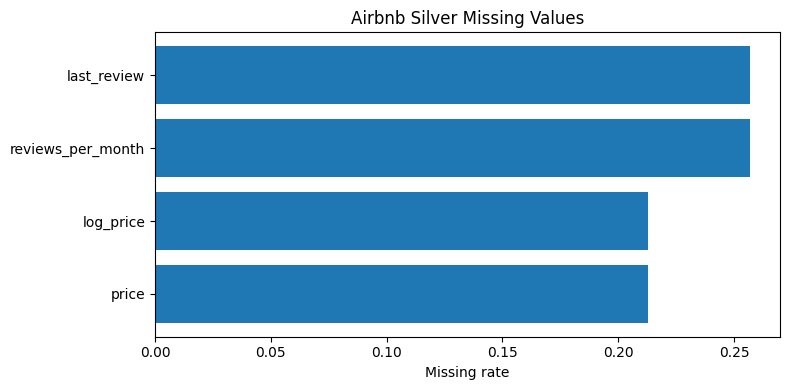

In [6]:
plot_missing = (
    missing_airbnb[missing_airbnb["missing_rate"] > 0]
    .sort_values("missing_rate", ascending=True)
)

plt.figure(figsize=(8, max(4, 0.35 * len(plot_missing))))
plt.barh(plot_missing["column"], plot_missing["missing_rate"])
plt.xlabel("Missing rate")
plt.title("Airbnb Silver Missing Values")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "airbnb_missing_values.png", dpi=300, bbox_inches="tight")
plt.show()

## Price and log price analysis

In [7]:
price_summary = airbnb["price"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).to_frame("price")

log_price_summary = airbnb["log_price"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).to_frame("log_price")

display(price_summary)
display(log_price_summary)

price_summary.to_csv(TABLES_DIR / "eda_price_summary.csv")
log_price_summary.to_csv(TABLES_DIR / "eda_log_price_summary.csv")

,price
count,15276.000000
mean,187.312713
std,363.967170
min,9.000000
1%,22.000000
5%,33.000000
25%,70.000000
50%,131.000000
75%,215.000000
95%,425.000000


,log_price
count,15276.000000
mean,4.828446
std,0.820964
min,2.197225
1%,3.091042
5%,3.496508
25%,4.248495
50%,4.875197
75%,5.370638
95%,6.052089


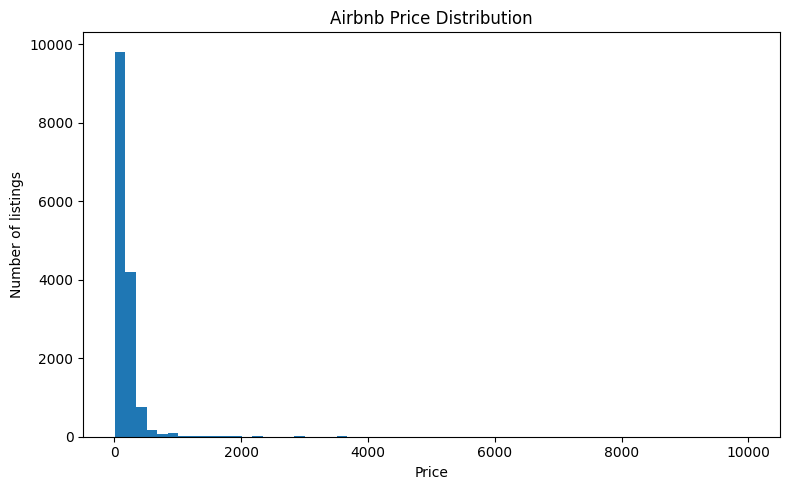

In [8]:
valid_price = airbnb.loc[airbnb["price"].notna() & (airbnb["price"] > 0), "price"]

plt.figure(figsize=(8, 5))
plt.hist(valid_price, bins=60)
plt.xlabel("Price")
plt.ylabel("Number of listings")
plt.title("Airbnb Price Distribution")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "airbnb_price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

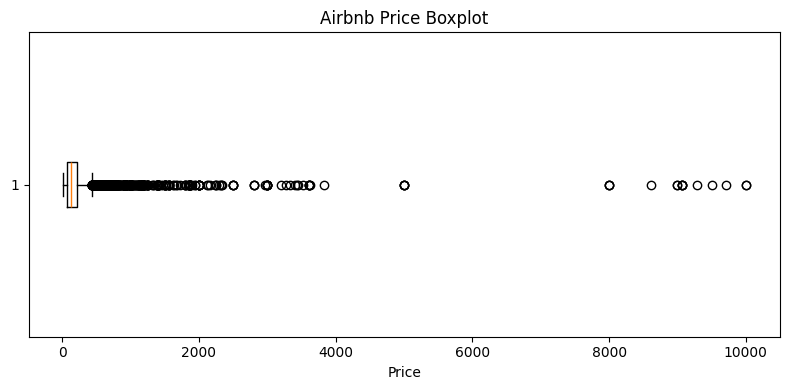

In [9]:
plt.figure(figsize=(8, 4))
plt.boxplot(valid_price, vert=False, showfliers=True)
plt.xlabel("Price")
plt.title("Airbnb Price Boxplot")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "airbnb_price_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

Given the price distribution we will be using log_price as a way of handling outliers without loosing other features information

## Text features: analysis

In [10]:
text_feature_cols = [
    "text_length",
    "word_count",
    "uppercase_ratio",
    "digit_count",
    "exclamation_count",
]

text_summary = airbnb[text_feature_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

display(text_summary)

text_summary.to_csv(TABLES_DIR / "eda_text_feature_summary.csv")

,text_length,word_count,uppercase_ratio,digit_count,exclamation_count
count,19410.000000,19410.000000,19410.000000,19410.000000,19410.000000
mean,35.576662,5.843740,0.147032,0.700927,0.053220
std,10.969267,2.041042,0.164477,1.346905,0.256205
min,1.000000,1.000000,0.000000,0.000000,0.000000
1%,9.000000,2.000000,0.000000,0.000000,0.000000
5%,17.000000,3.000000,0.027027,0.000000,0.000000
25%,28.000000,4.000000,0.066667,0.000000,0.000000
50%,36.000000,6.000000,0.111111,0.000000,0.000000
75%,45.000000,7.000000,0.166667,1.000000,0.000000
95%,50.000000,9.000000,0.360000,4.000000,0.000000


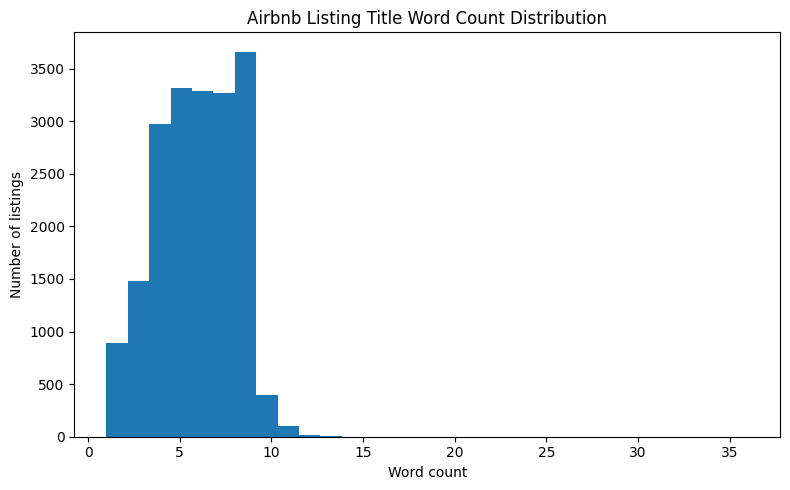

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(airbnb["word_count"].dropna(), bins=30)
plt.xlabel("Word count")
plt.ylabel("Number of listings")
plt.title("Airbnb Listing Title Word Count Distribution")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "airbnb_word_count_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

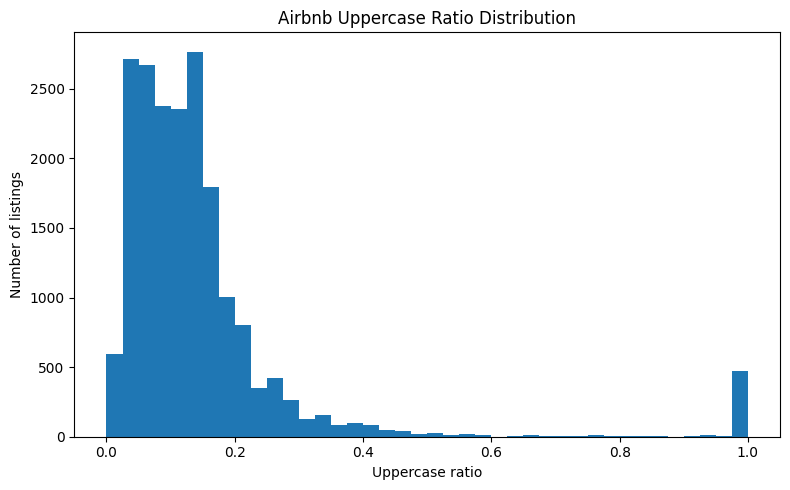

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(airbnb["uppercase_ratio"].dropna(), bins=40)
plt.xlabel("Uppercase ratio")
plt.ylabel("Number of listings")
plt.title("Airbnb Uppercase Ratio Distribution")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "airbnb_uppercase_ratio_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

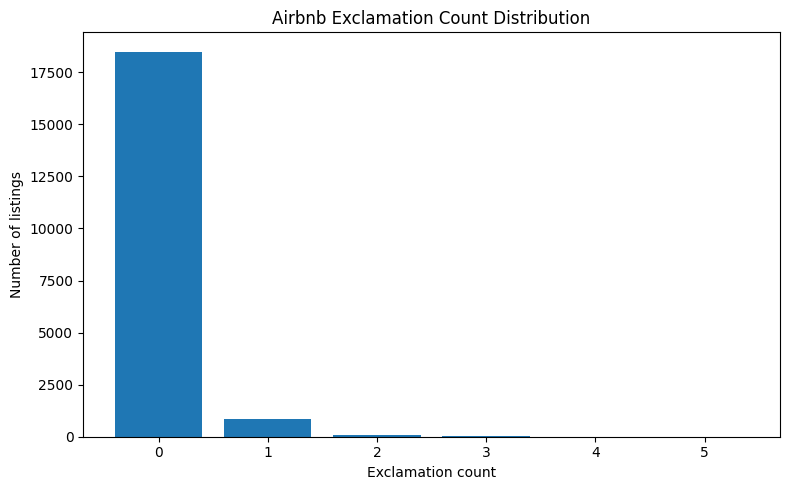

In [13]:
exclamation_counts = airbnb["exclamation_count"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(exclamation_counts.index.astype(str), exclamation_counts.values)
plt.xlabel("Exclamation count")
plt.ylabel("Number of listings")
plt.title("Airbnb Exclamation Count Distribution")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "airbnb_exclamation_count_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

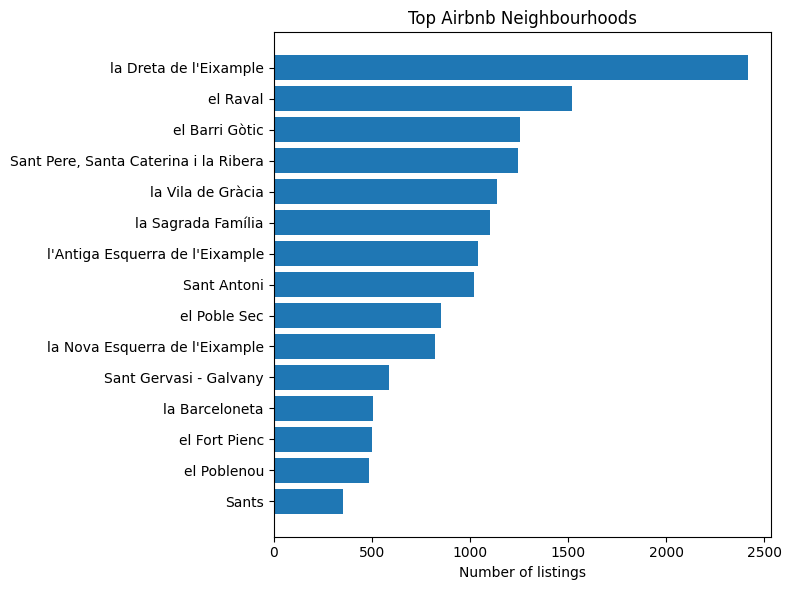

,count
neighbourhood,
la Dreta de l'Eixample,2416
el Raval,1519
el Barri Gòtic,1253
"Sant Pere, Santa Caterina i la Ribera",1244
la Vila de Gràcia,1136
la Sagrada Família,1102
l'Antiga Esquerra de l'Eixample,1042
Sant Antoni,1023
el Poble Sec,855


In [14]:
neighbourhood_counts = airbnb["neighbourhood"].value_counts().head(15)

plt.figure(figsize=(8, 6))
plt.barh(neighbourhood_counts.index[::-1], neighbourhood_counts.values[::-1])
plt.xlabel("Number of listings")
plt.title("Top Airbnb Neighbourhoods")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "airbnb_neighbourhood_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

display(neighbourhood_counts.to_frame("count"))
neighbourhood_counts.to_csv(TABLES_DIR / "eda_neighbourhood_counts.csv")

Our texts are very short so we will need to keep that in mind, also we see that there is an uneven distribution of Airbnbs by neighborhoods, sugesting location will be an important feature

## Activity related features

In [15]:
activity_cols = [
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",
    "number_of_reviews_ltm",
    "calculated_host_listings_count",
]

activity_summary = airbnb[activity_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

display(activity_summary)

activity_summary.to_csv(TABLES_DIR / "eda_activity_feature_summary.csv")

,minimum_nights,availability_365,number_of_reviews,reviews_per_month,number_of_reviews_ltm,calculated_host_listings_count
count,19410.000000,19410.000000,19410.000000,14421.000000,19410.000000,19410.000000
mean,15.953478,195.091190,52.512622,1.492801,11.345904,61.671716
std,31.054798,129.370782,110.713402,2.213720,23.533040,122.900150
min,1.000000,0.000000,0.000000,0.010000,0.000000,1.000000
1%,1.000000,0.000000,0.000000,0.010000,0.000000,1.000000
5%,1.000000,0.000000,0.000000,0.040000,0.000000,1.000000
25%,1.000000,72.000000,0.000000,0.210000,0.000000,2.000000
50%,3.000000,223.000000,6.000000,0.820000,1.000000,7.000000
75%,31.000000,318.000000,51.000000,2.220000,14.000000,40.000000
95%,33.000000,364.000000,270.000000,4.670000,50.000000,413.000000


## License treatment:
Inside airbnb has a record for each listing inside the license field, those are all either validated licenses, or listings exempt from needing license, since our goal is not to predict the type of license we create the flag `has_declared_license_text`

In [16]:
license_reference["has_declared_license_text"] = (
    license_reference["license_raw"]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
)

license_summary = (
    license_reference["has_declared_license_text"]
    .value_counts(normalize=True)
    .rename("proportion")
    .to_frame()
)

display(license_summary)

license_summary.to_csv(TABLES_DIR / "eda_license_declaration_summary.csv")

,proportion
has_declared_license_text,
True,0.717671
False,0.282329


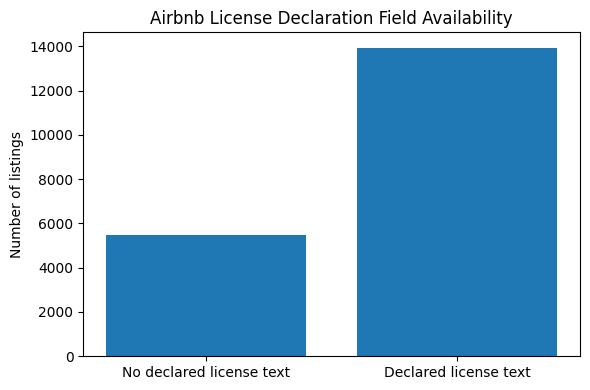

In [17]:
license_counts = (
    license_reference["has_declared_license_text"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(6, 4))
plt.bar(["No declared license text", "Declared license text"], license_counts.values)
plt.ylabel("Number of listings")
plt.title("Airbnb License Declaration Field Availability")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "airbnb_license_declaration_availability.png", dpi=300, bbox_inches="tight")
plt.show()

# License dataset

In [18]:
license_dataset_summary = pd.DataFrame({
    "metric": [
        "number_of_official_license_records",
        "valid_coordinate_rate",
        "number_of_districts",
        "number_of_neighborhoods",
        "median_license_places",
    ],
    "value": [
        len(licenses),
        licenses["has_valid_coordinates"].mean(),
        licenses["license_district"].nunique(),
        licenses["license_neighborhood"].nunique(),
        licenses["license_places"].median(),
    ],
})

display(license_dataset_summary)

license_dataset_summary.to_csv(TABLES_DIR / "eda_official_licenses_summary.csv", index=False)

,metric,value
0,number_of_official_license_records,6090.0
1,valid_coordinate_rate,1.0
2,number_of_districts,10.0
3,number_of_neighborhoods,66.0
4,median_license_places,6.0


## Licenses by district

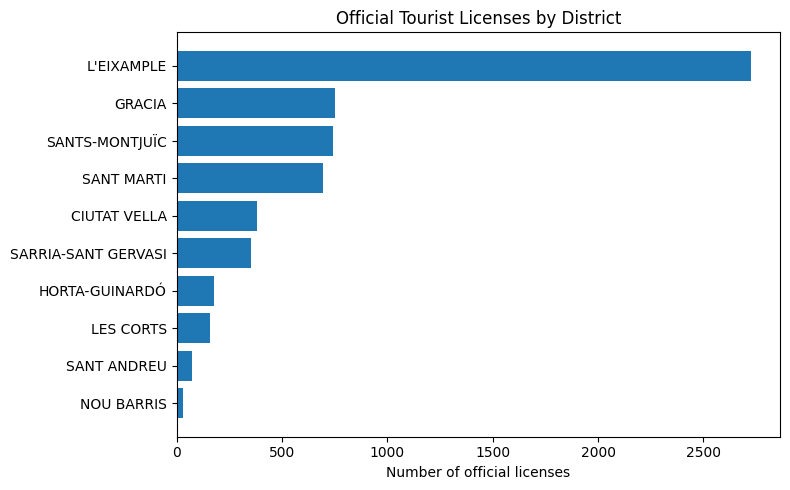

,count
license_district,
L'EIXAMPLE,2727
GRACIA,750
SANTS-MONTJUÏC,742
SANT MARTI,695
CIUTAT VELLA,383
SARRIA-SANT GERVASI,352
HORTA-GUINARDÓ,179
LES CORTS,158
SANT ANDREU,72


In [19]:
licenses_by_district = licenses["license_district"].value_counts().head(15)

plt.figure(figsize=(8, 5))
plt.barh(licenses_by_district.index[::-1], licenses_by_district.values[::-1])
plt.xlabel("Number of official licenses")
plt.title("Official Tourist Licenses by District")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "official_licenses_by_district.png", dpi=300, bbox_inches="tight")
plt.show()

display(licenses_by_district.to_frame("count"))
licenses_by_district.to_csv(TABLES_DIR / "eda_official_licenses_by_district.csv")

As seen with airbnb, districts are unevenly distributed

## Geospatial analysis:

In [20]:
coordinate_coverage = pd.DataFrame([
    {
        "dataset": "airbnb",
        "valid_coordinate_rate": airbnb["has_valid_coordinates"].mean(),
        "rows": len(airbnb),
    },
    {
        "dataset": "official_licenses",
        "valid_coordinate_rate": licenses["has_valid_coordinates"].mean(),
        "rows": len(licenses),
    },
])

display(coordinate_coverage)

coordinate_coverage.to_csv(TABLES_DIR / "eda_coordinate_coverage.csv", index=False)

,dataset,valid_coordinate_rate,rows
0,airbnb,1.0,19410
1,official_licenses,1.0,6090


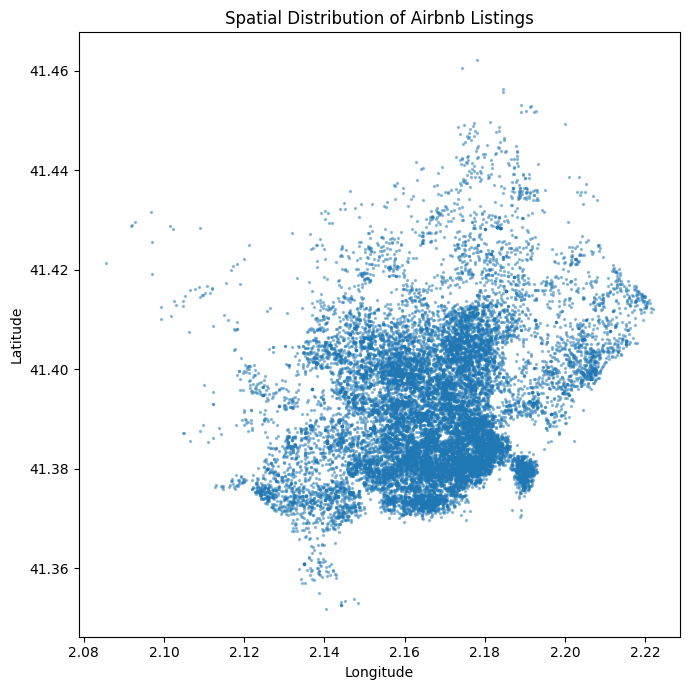

In [21]:
valid_airbnb_coords = airbnb[airbnb["has_valid_coordinates"]].copy()

plt.figure(figsize=(7, 7))
plt.scatter(
    valid_airbnb_coords["longitude"],
    valid_airbnb_coords["latitude"],
    s=2,
    alpha=0.4
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Airbnb Listings")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "airbnb_spatial_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

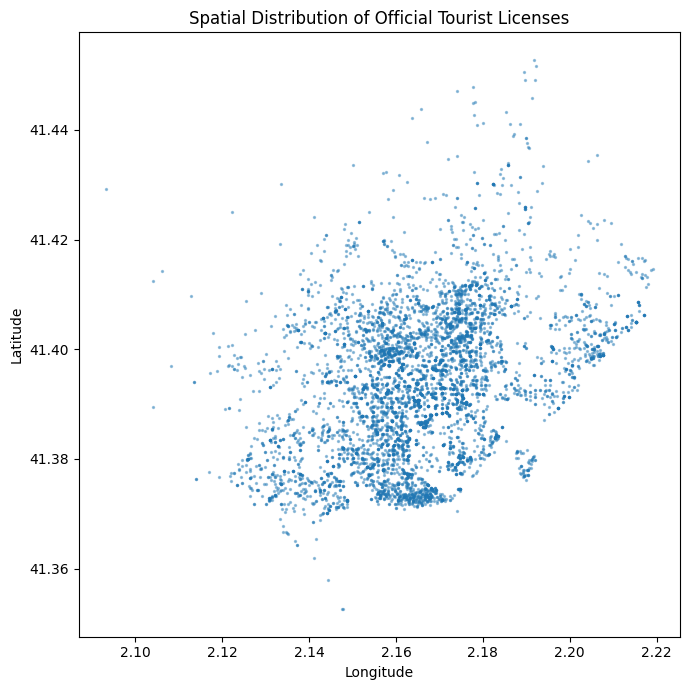

In [22]:
valid_license_coords = licenses[licenses["has_valid_coordinates"]].copy()

plt.figure(figsize=(7, 7))
plt.scatter(
    valid_license_coords["license_longitude"],
    valid_license_coords["license_latitude"],
    s=2,
    alpha=0.4
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Official Tourist Licenses")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "official_licenses_spatial_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

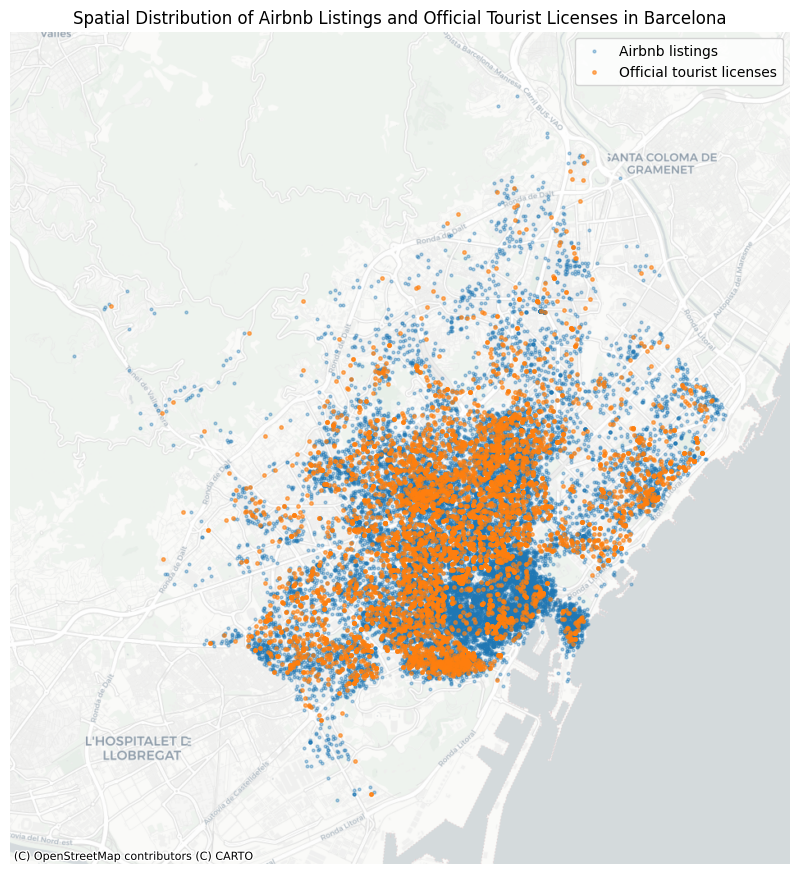

In [23]:
# ============================================================
# SPATIAL OVERLAY MAP: AIRBNB + OFFICIAL LICENSES + BARCELONA BASEMAP
# ============================================================

valid_airbnb_coords = airbnb[
    airbnb["has_valid_coordinates"]
    & airbnb["latitude"].notna()
    & airbnb["longitude"].notna()
].copy()

valid_license_coords = licenses[
    licenses["has_valid_coordinates"]
    & licenses["license_latitude"].notna()
    & licenses["license_longitude"].notna()
].copy()

# Build GeoDataFrames in WGS84
airbnb_gdf = gpd.GeoDataFrame(
    valid_airbnb_coords,
    geometry=gpd.points_from_xy(
        valid_airbnb_coords["longitude"],
        valid_airbnb_coords["latitude"]
    ),
    crs="EPSG:4326"
)

licenses_gdf = gpd.GeoDataFrame(
    valid_license_coords,
    geometry=gpd.points_from_xy(
        valid_license_coords["license_longitude"],
        valid_license_coords["license_latitude"]
    ),
    crs="EPSG:4326"
)

# Reproject to Web Mercator for basemap
airbnb_gdf = airbnb_gdf.to_crs(epsg=3857)
licenses_gdf = licenses_gdf.to_crs(epsg=3857)

# Define plot bounds with a small margin
minx = min(airbnb_gdf.total_bounds[0], licenses_gdf.total_bounds[0])
miny = min(airbnb_gdf.total_bounds[1], licenses_gdf.total_bounds[1])
maxx = max(airbnb_gdf.total_bounds[2], licenses_gdf.total_bounds[2])
maxy = max(airbnb_gdf.total_bounds[3], licenses_gdf.total_bounds[3])

margin = 1500

fig, ax = plt.subplots(figsize=(9, 9))

# Plot Airbnb listings
airbnb_gdf.plot(
    ax=ax,
    markersize=4,
    alpha=0.35,
    label="Airbnb listings"
)

# Plot official licenses
licenses_gdf.plot(
    ax=ax,
    markersize=6,
    alpha=0.60,
    label="Official tourist licenses"
)

# Set map extent
ax.set_xlim(minx - margin, maxx + margin)
ax.set_ylim(miny - margin, maxy + margin)

# Add Barcelona basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    crs=airbnb_gdf.crs
)

ax.set_title("Spatial Distribution of Airbnb Listings and Official Tourist Licenses in Barcelona")
ax.set_axis_off()
ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "airbnb_and_official_licenses_barcelona_map.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

As we can see, distributions present similar patterns, so we will be using the license dataset to enrich the airbnb dataset, since we cannot do it as an exact match or ground truth, we will later create mesures of license density as weak signals

## Outlier detection of price

In [24]:
def compute_iqr_outlier_flag(series):
    clean_series = series.dropna()

    q1 = clean_series.quantile(0.25)
    q3 = clean_series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    return (series < lower_bound) | (series > upper_bound), lower_bound, upper_bound


price_outlier_flag, price_lower, price_upper = compute_iqr_outlier_flag(airbnb["price"])
log_price_outlier_flag, log_price_lower, log_price_upper = compute_iqr_outlier_flag(airbnb["log_price"])

outlier_summary = pd.DataFrame([
    {
        "feature": "price",
        "lower_bound": price_lower,
        "upper_bound": price_upper,
        "outlier_rate": price_outlier_flag.mean(),
    },
    {
        "feature": "log_price",
        "lower_bound": log_price_lower,
        "upper_bound": log_price_upper,
        "outlier_rate": log_price_outlier_flag.mean(),
    },
])

display(outlier_summary)

outlier_summary.to_csv(TABLES_DIR / "eda_outlier_summary.csv", index=False)

,feature,lower_bound,upper_bound,outlier_rate
0,price,-147.500000,432.500000,0.038176
1,log_price,2.565281,7.053852,0.007831


Again, as we saw in the boxplot of price, this confirms that using log_price reduces the outlier variance without having to have them removed

## Correlation matrix

,price,log_price,minimum_nights,availability_365,number_of_reviews,reviews_per_month,number_of_reviews_ltm,calculated_host_listings_count,word_count,uppercase_ratio,digit_count,exclamation_count
price,1.000000,0.587560,-0.145096,0.062692,0.043012,0.012823,0.033477,0.085200,0.053272,0.010680,0.103867,0.069918
log_price,0.587560,1.000000,-0.365168,0.055768,0.218420,0.106586,0.197438,0.097550,0.094075,0.058786,0.065897,0.085547
minimum_nights,-0.145096,-0.365168,1.000000,0.018173,-0.164287,-0.204141,-0.178247,0.096502,-0.004570,-0.009222,-0.007263,-0.034068
availability_365,0.062692,0.055768,0.018173,1.000000,0.052643,0.107958,0.073676,0.191319,0.044068,0.006789,0.100006,0.017961
number_of_reviews,0.043012,0.218420,-0.164287,0.052643,1.000000,0.560900,0.744696,-0.162298,0.029450,0.091090,-0.033490,0.015733
reviews_per_month,0.012823,0.106586,-0.204141,0.107958,0.560900,1.000000,0.828291,-0.117055,-0.028890,0.003004,-0.026050,-0.009015
number_of_reviews_ltm,0.033477,0.197438,-0.178247,0.073676,0.744696,0.828291,1.000000,-0.142655,0.017466,0.037990,-0.011847,-0.008505
calculated_host_listings_count,0.085200,0.097550,0.096502,0.191319,-0.162298,-0.117055,-0.142655,1.000000,0.212472,-0.003101,0.279426,0.089789
word_count,0.053272,0.094075,-0.004570,0.044068,0.029450,-0.028890,0.017466,0.212472,1.000000,-0.061591,0.154280,0.090588
uppercase_ratio,0.010680,0.058786,-0.009222,0.006789,0.091090,0.003004,0.037990,-0.003101,-0.061591,1.000000,0.081456,0.016058


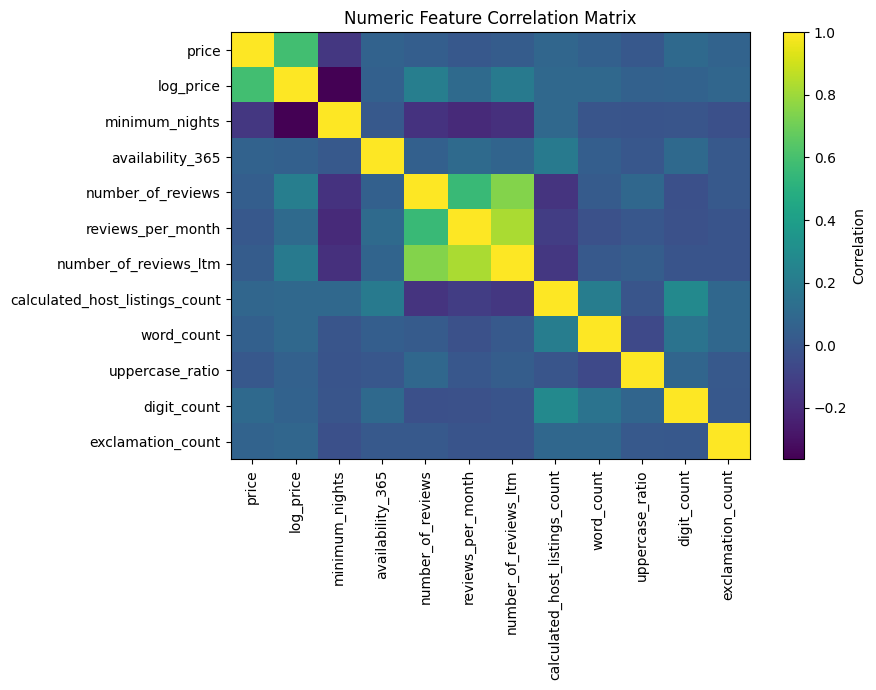

In [25]:
numeric_cols = [
    "price",
    "log_price",
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",
    "number_of_reviews_ltm",
    "calculated_host_listings_count",
    "word_count",
    "uppercase_ratio",
    "digit_count",
    "exclamation_count",
]

corr = airbnb[numeric_cols].corr()

display(corr)

corr.to_csv(TABLES_DIR / "eda_numeric_correlation_matrix.csv")

plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Numeric Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "airbnb_numeric_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

Final check for the numerical features, except the obvious `price` - `log-price` correlation, the rest of variables are mostly uncorrelated, meaning the model will not be over-influenced by redundancy

# Gold dataset construction

This final section converts the cleaned and explored Silver datasets into the final Gold modeling dataset.

The Gold layer contains only the data that will be used for model training and evaluation. It includes:
- cleaned Airbnb listing features;
- license-based geospatial features;
- the proxy target;
- train/test split;
- feature configuration.

The model training itself is intentionally left for Notebook 3.

## Geospatial enrichment:
As we said before we will create new variables for the gold data of license density

In [26]:
airbnb_geo = airbnb.copy()

valid_listing_mask = (
    airbnb_geo["has_valid_coordinates"]
    & airbnb_geo["latitude"].notna()
    & airbnb_geo["longitude"].notna()
)

valid_licenses = (
    licenses[
        licenses["has_valid_coordinates"]
        & licenses["license_latitude"].notna()
        & licenses["license_longitude"].notna()
    ]
    .copy()
    .reset_index(drop=True)
)

print("Valid Airbnb listing coordinates:", valid_listing_mask.sum(), "/", len(airbnb_geo))
print("Valid official license coordinates:", len(valid_licenses), "/", len(licenses))

Valid Airbnb listing coordinates: 19410 / 19410
Valid official license coordinates: 6090 / 6090


We are using Balltree algorithm with haversine distance metric to define the closest licenses and count licenses with a predefined radii, in our case we selected areas of 100, 250 and 500 meters

In [27]:
EARTH_RADIUS_M = 6_371_000

# Minimal and interpretable set of radii
LICENSE_RADII_METERS = [100, 250, 500]


def add_license_proximity_features(listings_df, licenses_df):
    """
    Add geospatial features based on proximity to official tourist licenses.
    Uses haversine distance through BallTree.
    """
    listings = listings_df.copy()

    # Initialize output columns
    listings["distance_to_nearest_license_m"] = np.nan
    listings["nearest_license_places"] = np.nan

    for radius_m in LICENSE_RADII_METERS:
        listings[f"licenses_within_{radius_m}m"] = np.nan
        listings[f"has_license_within_{radius_m}m"] = np.nan

    listings["license_density_250m_per_km2"] = np.nan
    listings["license_density_500m_per_km2"] = np.nan

    valid_listing_mask = (
        listings["has_valid_coordinates"]
        & listings["latitude"].notna()
        & listings["longitude"].notna()
    )

    valid_licenses = (
        licenses_df[
            licenses_df["has_valid_coordinates"]
            & licenses_df["license_latitude"].notna()
            & licenses_df["license_longitude"].notna()
        ]
        .copy()
        .reset_index(drop=True)
    )

    if valid_listing_mask.sum() == 0:
        print("No valid listing coordinates found.")
        return listings

    if len(valid_licenses) == 0:
        print("No valid license coordinates found.")
        return listings

    listing_coords_rad = np.radians(
        listings.loc[valid_listing_mask, ["latitude", "longitude"]].values
    )

    license_coords_rad = np.radians(
        valid_licenses[["license_latitude", "license_longitude"]].values
    )

    tree = BallTree(license_coords_rad, metric="haversine")

    valid_listing_idx = listings.loc[valid_listing_mask].index

    # Nearest license
    distances_rad, indices = tree.query(listing_coords_rad, k=1)
    distances_m = distances_rad[:, 0] * EARTH_RADIUS_M
    nearest_indices = indices[:, 0]

    nearest_license_rows = valid_licenses.iloc[nearest_indices].reset_index(drop=True)

    listings.loc[valid_listing_idx, "distance_to_nearest_license_m"] = distances_m

    if "license_places" in nearest_license_rows.columns:
        listings.loc[valid_listing_idx, "nearest_license_places"] = (
            nearest_license_rows["license_places"].values
        )

    # Counts within radii
    for radius_m in LICENSE_RADII_METERS:
        radius_rad = radius_m / EARTH_RADIUS_M
        neighbors = tree.query_radius(listing_coords_rad, r=radius_rad)
        counts = np.array([len(neighbor_indices) for neighbor_indices in neighbors])

        listings.loc[valid_listing_idx, f"licenses_within_{radius_m}m"] = counts
        listings.loc[valid_listing_idx, f"has_license_within_{radius_m}m"] = (
            counts > 0
        ).astype(int)

    # Density features
    for radius_m in [250, 500]:
        count_col = f"licenses_within_{radius_m}m"
        density_col = f"license_density_{radius_m}m_per_km2"
        area_km2 = np.pi * (radius_m / 1000) ** 2

        listings.loc[valid_listing_idx, density_col] = (
            listings.loc[valid_listing_idx, count_col] / area_km2
        )

    return listings


airbnb_enriched = add_license_proximity_features(airbnb_geo, valid_licenses)

print("Airbnb enriched shape:", airbnb_enriched.shape)
display(airbnb_enriched.head())

Airbnb enriched shape: (19410, 35)


,listing_key,text,neighbourhood_group,neighbourhood,municipality,latitude,longitude,has_valid_coordinates,property_type,minimum_nights,availability_365,price,log_price,has_invalid_price,number_of_reviews,last_review,reviews_per_month,number_of_reviews_ltm,calculated_host_listings_count,text_length,word_count,uppercase_ratio,digit_count,exclamation_count,empty_text,distance_to_nearest_license_m,nearest_license_places,licenses_within_100m,has_license_within_100m,licenses_within_250m,has_license_within_250m,licenses_within_500m,has_license_within_500m,license_density_250m_per_km2,license_density_500m_per_km2
0,airbnb_000000,Huge flat for 8 people close to Sagrada Familia,Eixample,la Sagrada Família,la Sagrada Família,41.405560,2.17262,True,Entire home/apt,1,80,210.0,5.347108,False,51,2025-07-31,0.34,7,26,47,9,0.078947,1,0,False,39.362063,6.0,14.0,1.0,135.0,1.0,378.0,1.0,687.549354,481.284548
1,airbnb_000001,"Forum CCIB DeLuxe, Spacious, Large Balcony, relax",Sant Martí,el Besòs i el Maresme,el Besòs i el Maresme,41.412432,2.21975,True,Entire home/apt,3,289,285.0,5.652489,False,91,2025-09-08,0.52,12,1,49,7,0.250000,0,0,False,156.163856,6.0,0.0,0.0,6.0,1.0,14.0,1.0,30.557749,17.825354
2,airbnb_000002,Sagrada Familia area - Còrsega 1,Gràcia,el Camp d'en Grassot i Gràcia Nova,el Camp d'en Grassot i Gràcia Nova,41.405660,2.17015,True,Entire home/apt,1,64,170.0,5.135798,False,152,2025-08-08,0.88,23,2,32,6,0.120000,1,0,False,1.677751,3.0,14.0,1.0,70.0,1.0,308.0,1.0,356.507073,392.157780
3,airbnb_000003,Stylish Top Floor Apartment - Ramblas Plaza Real,Ciutat Vella,el Barri Gòtic,el Barri Gòtic,41.380620,2.17517,True,Entire home/apt,31,333,110.0,4.700480,False,25,2024-11-05,0.14,5,3,48,8,0.175000,0,0,False,15.698072,4.0,26.0,1.0,73.0,1.0,170.0,1.0,371.785947,216.450723
4,airbnb_000004,VIDRE HOME PLAZA REAL on LAS RAMBLAS,Ciutat Vella,el Barri Gòtic,el Barri Gòtic,41.379780,2.17623,True,Entire home/apt,5,335,333.0,5.808142,False,271,2025-08-19,1.49,23,3,36,7,0.933333,0,0,False,0.403130,7.0,32.0,1.0,71.0,1.0,157.0,1.0,361.600031,199.898609


Since we obtain more information than the density, we decide to use it all as signals

In [28]:
geo_feature_cols = [
    "distance_to_nearest_license_m",
    "nearest_license_places",
    "licenses_within_100m",
    "licenses_within_250m",
    "licenses_within_500m",
    "has_license_within_100m",
    "has_license_within_250m",
    "has_license_within_500m",
    "license_density_250m_per_km2",
    "license_density_500m_per_km2",
]

geo_summary = airbnb_enriched[geo_feature_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

display(geo_summary)

geo_summary.to_csv(GOLD_GEOSPATIAL_FEATURE_SUMMARY_PATH)

,distance_to_nearest_license_m,nearest_license_places,licenses_within_100m,licenses_within_250m,licenses_within_500m,has_license_within_100m,has_license_within_250m,has_license_within_500m,license_density_250m_per_km2,license_density_500m_per_km2
count,19410.000000,19114.000000,19410.000000,19410.000000,19410.000000,19410.000000,19410.000000,19410.000000,19410.000000,19410.000000
mean,50.746155,6.164173,9.809737,54.821896,198.150644,0.898454,0.986141,0.997372,279.205623,252.293236
std,60.413298,3.506128,9.186966,37.668960,120.581196,0.302058,0.116908,0.051193,191.846438,153.528747
min,0.002767,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1%,1.147809,2.000000,0.000000,0.000000,3.000000,0.000000,0.000000,1.000000,0.000000,3.819719
5%,4.167255,2.000000,0.000000,4.000000,19.000000,0.000000,1.000000,1.000000,20.371833,24.191551
25%,18.065451,4.000000,3.000000,24.000000,97.000000,1.000000,1.000000,1.000000,122.230996,123.504236
50%,36.209063,5.000000,7.000000,48.000000,174.000000,1.000000,1.000000,1.000000,244.461993,221.543681
75%,63.412221,8.000000,15.000000,83.000000,312.000000,1.000000,1.000000,1.000000,422.715529,397.250738
95%,137.343117,12.000000,28.000000,121.000000,390.000000,1.000000,1.000000,1.000000,616.247940,496.563422


In [29]:
airbnb_enriched.to_parquet(AIRBNB_LICENSE_ENRICHED_PATH, index=False)

print("Saved:", AIRBNB_LICENSE_ENRICHED_PATH)

Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\data\gold\airbnb_license_enriched.parquet


## Proxy target construction

The project does not have confirmed legal fraud labels.

Therefore, the supervised target is constructed as a proxy for possible regulatory non-compliance using the Airbnb license declaration field.

Definition:
- `potentially_unlicensed = 0`: the listing declares a non-empty license value, meaning we have valid information about the license status.
- `potentially_unlicensed = 1`: the listing does not declare a license value.

This target is not confirmed legal fraud. It is a proxy risk label.

In [30]:
modeling_base = airbnb_enriched.merge(
    license_reference,
    on="listing_key",
    how="left",
    validate="one_to_one"
)

print("Modeling base shape:", modeling_base.shape)
display(modeling_base[["listing_key", "license_raw"]].head())

Modeling base shape: (19410, 37)


,listing_key,license_raw
0,airbnb_000000,ESFCTU000008058000039706000000000000000HUTB-002062349
1,airbnb_000001,ESFCTU000008106000547162000000000000000000HUTB0050572
2,airbnb_000002,HUTB-001722
3,airbnb_000003,Exempt
4,airbnb_000004,ESFCTU000008119000093652000000000000000HUTB-001506712


In [31]:
modeling_base["has_declared_license"] = (
    modeling_base["license_raw"]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
)

modeling_base["potentially_unlicensed"] = (
    ~modeling_base["has_declared_license"]
).astype(int)

target_counts = (
    modeling_base["potentially_unlicensed"]
    .value_counts()
    .rename("count")
    .to_frame()
)

target_distribution = (
    modeling_base["potentially_unlicensed"]
    .value_counts(normalize=True)
    .rename("proportion")
    .to_frame()
)

target_summary = target_counts.join(target_distribution)

display(target_summary)

target_summary.to_csv(GOLD_TARGET_DISTRIBUTION_PATH)

,count,proportion
potentially_unlicensed,,
0,13930,0.717671
1,5480,0.282329


## Final Gold Dataset:
After the Exploratory Data Analysis, this is our list of selected features

In [32]:
# ============================================================
# GOLD X. DEFINE FINAL MODELING FEATURES
# ============================================================

numeric_features = [
    # Economic
    "log_price",

    # Listing / activity
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",
    "number_of_reviews_ltm",
    "calculated_host_listings_count",

    # Objective text features
    "word_count",
    "uppercase_ratio",
    "digit_count",
    "exclamation_count",

    # Geospatial / regulatory features
    "distance_to_nearest_license_m",
    "nearest_license_places",
    "licenses_within_100m",
    "licenses_within_250m",
    "licenses_within_500m",
    "has_license_within_100m",
    "has_license_within_250m",
    "has_license_within_500m",
    "license_density_250m_per_km2",
    "license_density_500m_per_km2",
]

categorical_features = [
    "property_type",
    "neighbourhood",
]

text_features = [
    "text",
]

target_col = "potentially_unlicensed"

# Features used by classical/tabular models
selected_features = numeric_features + categorical_features + text_features



print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Text features:", len(text_features))
print("Total selected tabular features:", len(selected_features))
print("Target:", target_col)

Numeric features: 21
Categorical features: 2
Text features: 1
Total selected tabular features: 24
Target: potentially_unlicensed


## Nan handling

First we eliminate nans of crucial features for our model, coordinates which are the base of our innovation and our target

In [33]:
modeling_base = modeling_base.copy()

# Keep records with valid target
modeling_base = modeling_base[
    modeling_base[target_col].notna()
].copy()


# Keep records with valid coordinates because geospatial enrichment is central
modeling_base = modeling_base[
    modeling_base["has_valid_coordinates"]
].copy()

# Keep only selected features and target
modeling_dataset = modeling_base[selected_features + [target_col]].copy()

print("Gold modeling dataset shape:", modeling_dataset.shape)
display(modeling_dataset.head())

Gold modeling dataset shape: (19410, 25)


,log_price,minimum_nights,availability_365,number_of_reviews,reviews_per_month,number_of_reviews_ltm,calculated_host_listings_count,word_count,uppercase_ratio,digit_count,exclamation_count,distance_to_nearest_license_m,nearest_license_places,licenses_within_100m,licenses_within_250m,licenses_within_500m,has_license_within_100m,has_license_within_250m,has_license_within_500m,license_density_250m_per_km2,license_density_500m_per_km2,property_type,neighbourhood,text,potentially_unlicensed
0,5.347108,1,80,51,0.34,7,26,9,0.078947,1,0,39.362063,6.0,14.0,135.0,378.0,1.0,1.0,1.0,687.549354,481.284548,Entire home/apt,la Sagrada Família,Huge flat for 8 people close to Sagrada Familia,0
1,5.652489,3,289,91,0.52,12,1,7,0.250000,0,0,156.163856,6.0,0.0,6.0,14.0,0.0,1.0,1.0,30.557749,17.825354,Entire home/apt,el Besòs i el Maresme,"Forum CCIB DeLuxe, Spacious, Large Balcony, relax",0
2,5.135798,1,64,152,0.88,23,2,6,0.120000,1,0,1.677751,3.0,14.0,70.0,308.0,1.0,1.0,1.0,356.507073,392.157780,Entire home/apt,el Camp d'en Grassot i Gràcia Nova,Sagrada Familia area - Còrsega 1,0
3,4.700480,31,333,25,0.14,5,3,8,0.175000,0,0,15.698072,4.0,26.0,73.0,170.0,1.0,1.0,1.0,371.785947,216.450723,Entire home/apt,el Barri Gòtic,Stylish Top Floor Apartment - Ramblas Plaza Real,0
4,5.808142,5,335,271,1.49,23,3,7,0.933333,0,0,0.403130,7.0,32.0,71.0,157.0,1.0,1.0,1.0,361.600031,199.898609,Entire home/apt,el Barri Gòtic,VIDRE HOME PLAZA REAL on LAS RAMBLAS,0


In [34]:
gold_candidate = modeling_base.copy()

gold_missing_audit = (
    pd.DataFrame({
        "column": gold_candidate.columns,
        "dtype": [str(gold_candidate[col].dtype) for col in gold_candidate.columns],
        "missing_count": [gold_candidate[col].isna().sum() for col in gold_candidate.columns],
        "missing_rate": [gold_candidate[col].isna().mean() for col in gold_candidate.columns],
        "non_null_count": [gold_candidate[col].notna().sum() for col in gold_candidate.columns],
        "unique_count": [gold_candidate[col].nunique(dropna=True) for col in gold_candidate.columns],
    })
    .query("missing_count > 0")
    .sort_values("missing_rate", ascending=False)
    .reset_index(drop=True)
)

display(gold_missing_audit)

gold_missing_audit.to_csv(
    TABLES_DIR / "gold_missing_audit_before_filtering.csv",
    index=False
)

,column,dtype,missing_count,missing_rate,non_null_count,unique_count
0,last_review,datetime64[us],4989,0.257032,14421,1837
1,reviews_per_month,float64,4989,0.257032,14421,835
2,price,float64,4134,0.212983,15276,772
3,log_price,float64,4134,0.212983,15276,772
4,nearest_license_places,float64,296,0.015250,19114,32


For the rest of our nans we decide for each what is best to do

In [35]:
modeling_base = modeling_base.copy()

# reviews_per_month is missing when the listing has no reviews.
# In that case, the observed review activity is interpreted as zero.
modeling_base["reviews_per_month"] = modeling_base["reviews_per_month"].fillna(0)


# nearest_license_places may be missing when the nearest official license
# has no number of places reported. The nearest license still exists, so
# we impute this auxiliary contextual feature with the median.
nearest_places_missing_before = modeling_base["nearest_license_places"].isna().sum()
nearest_places_median = modeling_base["nearest_license_places"].median()

modeling_base["nearest_license_places"] = (
    modeling_base["nearest_license_places"]
    .fillna(nearest_places_median)
)

# price and log_price are core economic features.
# Listings without valid price information are excluded from the Gold modeling dataset.
before_filtering = len(modeling_base)

modeling_base = modeling_base[
    modeling_base["price"].notna()
    & modeling_base["log_price"].notna()
].copy()

after_filtering = len(modeling_base)

print("Rows before price/log_price filtering:", before_filtering)
print("Rows after price/log_price filtering:", after_filtering)
print("Rows removed due to missing price/log_price:", before_filtering - after_filtering)
print("Removal rate:", (before_filtering - after_filtering) / before_filtering)

Rows before price/log_price filtering: 19410
Rows after price/log_price filtering: 15276
Rows removed due to missing price/log_price: 4134
Removal rate: 0.21298299845440494


In [36]:
missing_selected_features = [
    col for col in selected_features + [target_col]
    if col not in modeling_base.columns
]

if missing_selected_features:
    raise ValueError(f"Missing columns in Gold dataset: {missing_selected_features}")

if modeling_base[target_col].isna().any():
    raise ValueError("Target contains missing values.")

if not set(modeling_base[target_col].unique()).issubset({0, 1}):
    raise ValueError("Target must be binary with values 0 and 1.")

print("Gold dataset validation passed.")

Gold dataset validation passed.


In [37]:
modeling_base.to_parquet(AIRBNB_MODELING_DATASET_PATH, index=False)

feature_config = {
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "text_features": text_features,
    "selected_features": selected_features,
    "target": target_col,
}

with open(FEATURE_CONFIG_PATH, "w", encoding="utf-8") as file:
    json.dump(feature_config, file, indent=4)

print("Saved:", AIRBNB_MODELING_DATASET_PATH)
print("Saved:", FEATURE_CONFIG_PATH)

Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\data\gold\airbnb_modeling_dataset.parquet
Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\data\gold\feature_config.json


Finally we create three splits, training, validation and testing, each of them will have a diferent function in the modeling section

In [38]:
def train_val_test_split(
    X,
    y,
    train_size=0.60,
    val_size=0.20,
    test_size=0.20,
    random_state=42,
):
    """
    Create stratified train/validation/test splits.

    Default split:
    - 60% train
    - 20% validation
    - 20% test
    """

    total_size = train_size + val_size + test_size

    if not abs(total_size - 1.0) < 1e-8:
        raise ValueError("train_size + val_size + test_size must sum to 1.")

    # First split: train vs temporary set
    X_train, X_temp, y_train, y_temp = train_test_split(
        X,
        y,
        test_size=(val_size + test_size),
        random_state=random_state,
        stratify=y,
    )

    # Second split: validation vs test
    relative_test_size = test_size / (val_size + test_size)

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=relative_test_size,
        random_state=random_state,
        stratify=y_temp,
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

In [39]:
X = modeling_base[selected_features].copy()
y = modeling_base[target_col].copy()

X_train, X_test, X_val, y_train, y_test, y_val = train_val_test_split(
    X,
    y,
    test_size=0.20,
    val_size=0.20,
    random_state=42,
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("X_val shape:", X_val.shape)

print("\nTrain target distribution:")
display(y_train.value_counts(normalize=True).to_frame("proportion"))

print("\nTest target distribution:")
display(y_test.value_counts(normalize=True).to_frame("proportion"))

print("\nValidation target distribution:")
display(y_val.value_counts(normalize=True).to_frame("proportion"))

X_train shape: (9165, 24)
X_test shape: (3055, 24)
X_val shape: (3056, 24)

Train target distribution:


,proportion
potentially_unlicensed,
0,0.768685
1,0.231315



Test target distribution:


,proportion
potentially_unlicensed,
0,0.768576
1,0.231424



Validation target distribution:


,proportion
potentially_unlicensed,
0,0.768652
1,0.231348


In [40]:
X_train.to_parquet(X_TRAIN_PATH, index=False)
X_test.to_parquet(X_TEST_PATH, index=False)
X_val.to_parquet(X_VAL_PATH, index=False)

y_train.to_frame(target_col).to_parquet(Y_TRAIN_PATH, index=False)
y_test.to_frame(target_col).to_parquet(Y_TEST_PATH, index=False)
y_val.to_frame(target_col).to_parquet(Y_VAL_PATH, index=False)

print("Saved:", X_TRAIN_PATH)
print("Saved:", X_TEST_PATH)
print("Saved:", X_VAL_PATH)
print("Saved:", Y_TRAIN_PATH)
print("Saved:", Y_TEST_PATH)
print("Saved:", Y_VAL_PATH)

print("\nSaved shapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print("y_val:", y_val.shape)

Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\data\gold\X_train.parquet
Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\data\gold\X_test.parquet
Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\data\gold\X_val.parquet
Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\data\gold\y_train.parquet
Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\data\gold\y_test.parquet
Saved: c:\Users\David\Documents\TFG\Fraudulent_property_listing_detection_tool\tool\data\gold\y_val.parquet

Saved shapes:
X_train: (9165, 24)
X_test: (3055, 24)
X_val: (3056, 24)
y_train: (9165,)
y_test: (3055,)
y_val: (3056,)


## Gold dataset output summary

This section created the final Gold modeling layer.

Generated outputs:
- `data/gold/airbnb_license_enriched.parquet`
- `data/gold/airbnb_modeling_dataset.parquet`
- `data/gold/X_train.parquet`
- `data/gold/X_test.parquet`
- `data/gold/y_train.parquet`
- `data/gold/y_test.parquet`
- `data/gold/feature_config.json`

The next notebook will only train and evaluate models using these Gold files.